In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"H:\python\3etapa\nada\Tabela 1.1.1.xls"
bruto = pd.read_excel(path, engine="xlrd", header=None)

indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

In [3]:
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

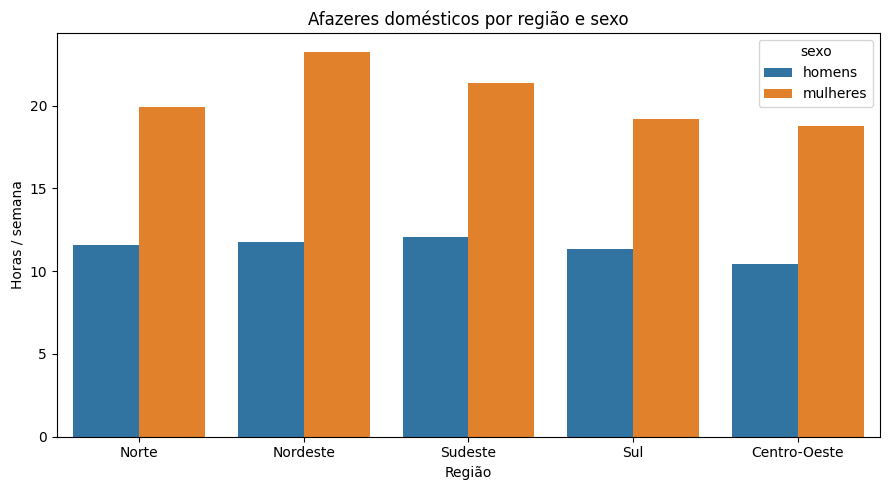

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()

## Atividade 3 - Formação acadêmica por área e sexo

In [5]:
path = r"H:\python\3etapa\nada\Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"
bruto_formacao = pd.read_excel(path, header=None)

dados = bruto_formacao.iloc[3:36].reset_index(drop=True)

for col in range(1, 10):
    dados[col] = pd.to_numeric(dados[col])

formacao_total = dados[[0, 2, 3]].copy()
formacao_total.columns = ["uf_regiao", "total_homens", "total_mulheres"]

formacao_stem = dados[[0, 5, 6]].copy()
formacao_stem.columns = ["uf_regiao", "homens", "mulheres"]

formacao_saude = dados[[0, 8, 9]].copy()
formacao_saude.columns = ["uf_regiao", "homens", "mulheres"]

In [6]:
brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_homens"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "homens"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "homens"].item(),
        ],
        "mulheres": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_mulheres"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "mulheres"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "mulheres"].item(),
        ],
    }
)
brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

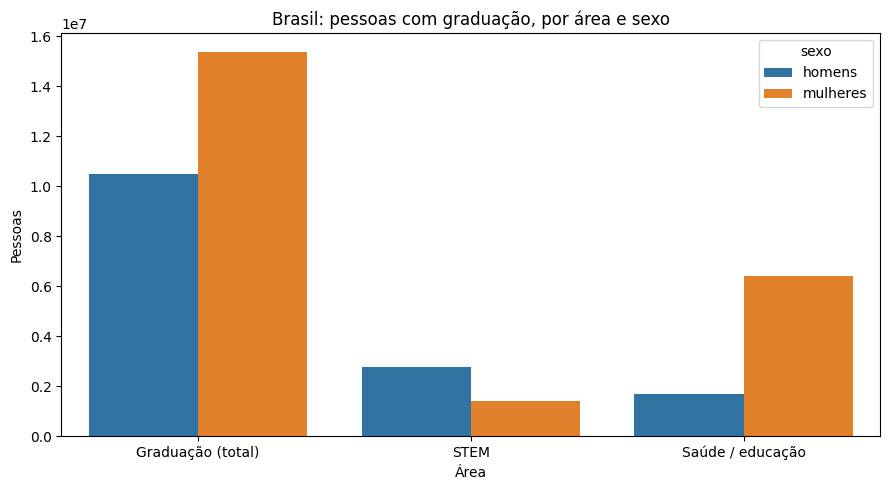

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()